In [1]:
import networkx as nx
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
grafo = nx.read_gml('grafo.gml')

In [13]:
gf = nx.scale_free_graph(n = 126, alpha =0.12,  beta = 0.54, gamma = (1-0.54-0.12))
layout = nx.spring_layout(gf)

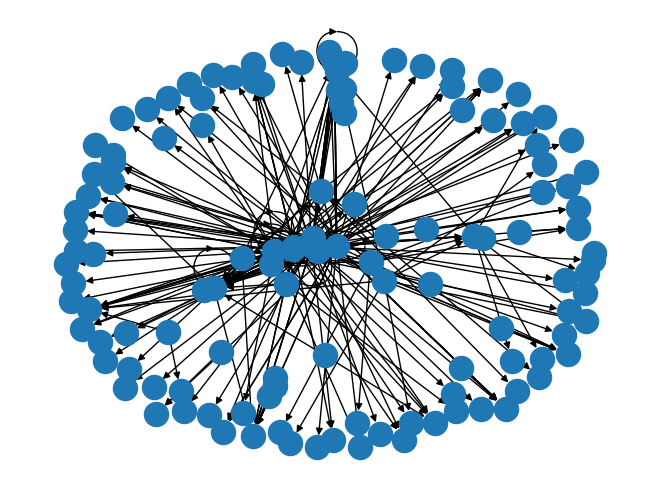

In [14]:
nx.draw(gf, pos = layout)

In [28]:
gf.add_nodes_from(grafo.nodes())

In [30]:
gf.add_edges_from(grafo.edges());

In [72]:
dados = pd.DataFrame(columns=['nos_gf', 'nos_g', 'centralidade_gf', 'centralidade_g'])

In [73]:
dados['nos_gf'] = list(gf.nodes())
dados['centralidade_gf'] =  nx.closeness_centrality(gf)

In [74]:
dados

,nos_gf,nos_g,centralidade_gf,centralidade_g
0,0,NaN,0.434559,NaN
1,1,NaN,0.336325,NaN
2,2,NaN,0.341560,NaN
3,3,NaN,0.365754,NaN
4,4,NaN,0.312388,NaN
...,...,...,...,...
174,diogoandradesou,NaN,NaN,NaN
175,vitu_42,NaN,NaN,NaN
176,benvindasjdr,NaN,NaN,NaN
177,ana_lu.032,NaN,NaN,NaN


In [50]:
from faker import Faker
fake = Faker()

In [ ]:
for j in range(0, 178-126):
    fake = Faker()
    fknm = fake.name()
    #print(fknm.replace(' ', '_').lower())
    dados['nos_gf'][j] = fknm.replace(' ', '_').lower();

In [78]:
gf2 = nx.Graph()
gf2.add_nodes_from(dados['nos_gf'])

In [94]:
for u,v in gf2.edges():
    p = np.random.rand()
    nos = list(gf2.nodes())
    if p <= 0.8:
        gf2.add_edge(nos[np.random.randint(0, gf2.order())], nos[np.random.randint(0, gf2.order())])

In [ ]:
#centralidades = nx.closeness_centrality(gf)
nx.set_node_attributes(gf, centralidades, 'centrality')


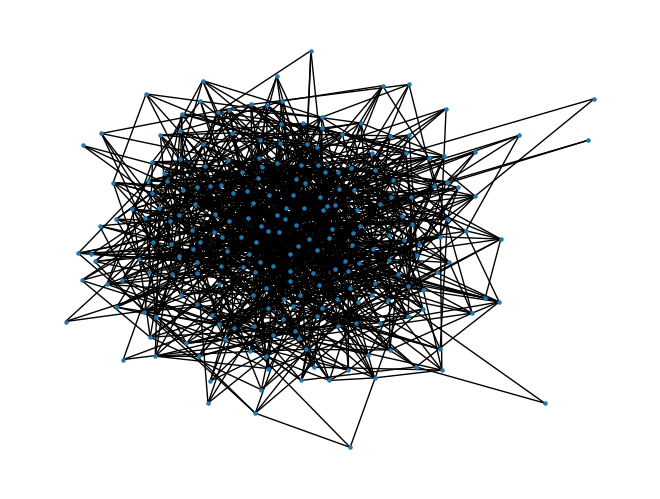

In [95]:
nx.draw(gf2, node_size = 5)

{'stacey_warner': 0, 'jane_ford': 6, 'jesse_kelly': 4, 'patricia_ellis': 6, 'ann_torres': 6, 'regina_oliver': 8, 'michelle_king': 5, 'tracy_hill': 4, 'karen_lopez': 5, 'claudia_duran': 3, 'brandon_fisher': 8, 'mr._thomas_curtis': 1, 'ricardo_oneal': 7, 'patricia_scott': 5, 'victoria_guerrero': 8, 'ricky_anderson': 2, 'jorge_bonilla': 1, 'alicia_silva': 6, 'todd_campos': 1, 'tina_white': 8, 'nicholas_foster': 0, 'stephanie_jensen': 5, 'ronald_anthony': 7, 'megan_fields': 0, 'paul_nguyen': 6, 'christopher_bryant': 5, 'joseph_jones': 4, 'lauren_lopez': 0, 'jake_poole': 7, 'amanda_juarez': 7, 'karen_cox': 4, 'elizabeth_black': 0, 'lori_roy': 8, 'danny_castillo': 5, 'gary_anderson': 4, 'bethany_smith': 7, 'sabrina_moreno': 8, 'mrs._amy_conley': 4, 'dennis_wallace': 2, 'tara_chang': 1, 'darrell_kim': 1, 'emily_spears': 7, 'jackson_santos': 6, 'james_miller_jr.': 0, 'amanda_miller': 3, 'amber_meyer': 1, 'cory_phillips_dds': 0, 'cameron_rivas': 8, 'erica_vaughn': 6, 'jade_hayes': 3, 'matthew_p

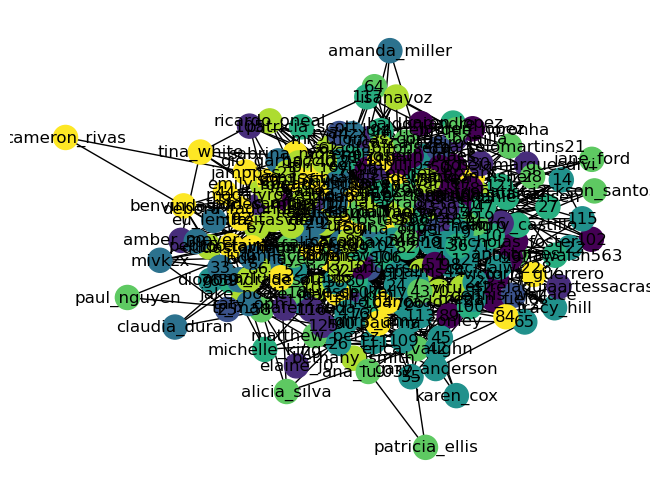

In [97]:
import community as community_louvain 
gf = nx.Graph(gf2)
partition = community_louvain.best_partition(gf2)

# A partição é um dicionário: {nó: comunidade}
print(partition)

# Visualização opcional
# Cores para cada comunidade
import matplotlib.cm as cm
values = [partition[node] for node in gf2.nodes()]
cmap = cm.get_cmap('viridis', max(values)+1)

nx.draw(gf, node_color=values, with_labels=True, cmap=cmap)
plt.show()